In [ ]:
!pip install torch torchvision -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Загрузка данных

In [ ]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print("train:", train_df.shape)
print("test: ", test_df.shape)

# убираем столбец с ответами, переводим для пайторч в float32, нормализуем пиксели в диапазон [0, 1]
# X — входные данные (признаки)
X = train_df.drop('label', axis=1).values.astype('float32') / 255.0
# берём только столбец с правильными ответами. int64 — целые числа для функции потерь.
# y — правильные ответы
y = train_df['label'].values.astype('int64')
# для теста
X_test = test_df.values.astype('float32') / 255.0

# обучение - 90
# stratify=y — в обоих частях будет одинаковое соотношение цифр
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Обучение: {X_train.shape}, Пробное тестирование: {X_val.shape}")

train: (42000, 785)
test:  (28000, 784)
Обучение: (37800, 784), Пробное тестирование: (4200, 784)


Датасет и функции для обучения

In [ ]:
# класс датасета
class DigitDataset(Dataset):
    def __init__(self, X, y=None, mode='flat'): # для тестовых данных меток нет
    # вектор - одномерный тензор
    # без self данные исчезли бы после завершения __init__
        self.X = X
        self.y = y
        self.mode = mode

# возвращает количество строк в X
    def __len__(self):
        return len(self.X)

# когда DataLoader запрашивает конкретный пример по номеру
    def __getitem__(self, idx):
      # конвертируем NumPy массив в тензор PyTorch, чтобы работать с ними
        img = torch.tensor(self.X[idx])

# был вектор (784). стал трёхмерный тензор (1, 28, 28)
        if self.mode == 'image':
            img = img.reshape(1, 28, 28)

# метки есть (обучение или тестовая проверка) — картинка + правильный ответ.
# меток нет (тестовые данные) — только картинка.
# из таких пар формируются батчи
        if self.y is not None:
            return img, torch.tensor(self.y[idx])
        return img


# одна эпоха обучения
# criterion — функция потерь, измеряет ошибку
# optimizer — алгоритм который обновляет веса.
def train_epoch(model, loader, criterion, optimizer):
    model.train() # переключает модель в режим обучения
    # total_loss — накапливаем суммарную ошибку за все батчи
    # correct — считаем количество верных предсказаний
    # total — считаем общее количество примеров
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad() # обнуляем градиенты
        # прямой проход — прогоняем батч через всю нейросеть.
        # out — результат, тензор формы (128, 10)
        out  = model(X_b)
        loss = criterion(out, y_b)
        # обратный проход — вычисляем градиенты (диф-е)
        loss.backward()
        optimizer.step()
        # обновление весов
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


# оценка по пробному тестированию (валидации)
# декоратор —  не вычислять градиенты внутри этой функции.
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval() # модель в режиме оценки
    total_loss, correct, total = 0, 0, 0
    # идентично обучению, но без обновления весов
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        out  = model(X_b)
        loss = criterion(out, y_b)
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total


# полный цикл обучения
def fit(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    # CrossEntropyLoss — функция потерь для классификации
    # Adam — оптимизатор, подстраивает скорость обучения для каждого веса отдельно.
    # model.parameters() — передаём все веса модели которые нужно обновлять.
    # lr=1e-3 — learning rate = 0.001, размер шага при обновлении весов.
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs + 1):
      # сначала обучаемся на train, потом проверяемся на val
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        print(f"Эпоха {epoch:02d} | "
              f"Потери на обучении: {tr_loss:.4f}, точность: {tr_acc:.4f} | "
              f"Потери на валидации: {vl_loss:.4f}, точность: {vl_acc:.4f}")

    print(f"\nИтоговая точность на валидации: {vl_acc*100:.2f}%")
    return model

Визуализация (для графика эпох)

In [ ]:
# график обучения
def plot_history(train_accs, val_accs, title):
    plt.figure(figsize=(7, 4))
    plt.plot(train_accs, label='Train')
    plt.plot(val_accs,   label='Val')
    plt.title(f'{title} — Процент правильнх ответов по эпохам')
    plt.xlabel('Эпоха')
    plt.ylabel('Процент правильных ответов')
    plt.legend()
    plt.grid(True)
    plt.show()

МНОГОСЛОЙНЫЙ ПЕРЦЕПТРОН

Архитектура MLP (многослойный перцептрон):
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=10, bias=True)
)
Эпоха 01 | точность на обучении: 0.8534 | точность на валидации: 0.9345
Эпоха 02 | точность на обучении: 0.9357 | точность на валидации: 0.9562
Эпоха 03 | точность на обучении: 0.9551 | точность на валидации: 0.9612
Эпоха 04 | точность на обучении: 0.9631 | точность на валидации: 0.9679
Эпоха 05 | точность на обучении: 0.9692 | точность на валидации: 0.9712
Эпоха 06 | точность на обучении: 0.9730 | точность на валидации: 0.9729
Эпоха 07 | точность на обучении: 0.9773 | точность на валидации: 0.9745
Эпоха 08 | точность на обучении: 0.9797 | точность на валидации: 0.9707
Эпоха 09 | точность на обучении: 0.9819 | точность на валидации: 0.9740
Эпоха 10 | точ

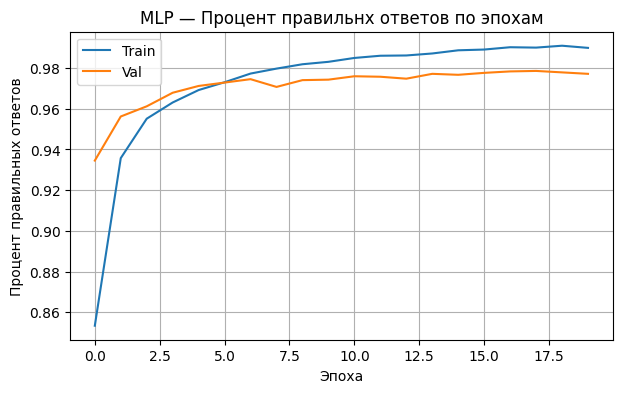

In [ ]:
mlp = nn.Sequential( # контейнер который складывает слои в очередь
    # полносвязный слой, на вход 28х28=784, на выходе 256 нейронов
    # ReLU добавляет нелинейность
    # случайно отключает 30% нейронов в каждом батче
    nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128,  10)
).to(device)

print("Архитектура MLP (многослойный перцептрон):")
print(mlp)

# создаётся датасет из обучающих данных в режиме flat
# shuffle - перемешиваются данные перед каждой эпохой
train_loader = DataLoader(DigitDataset(X_train, y_train, mode='flat'), batch_size=128, shuffle=True)
# датасет для валидации
val_loader   = DataLoader(DigitDataset(X_val,   y_val,   mode='flat'), batch_size=128)

# измеряет насколько плохо модель предсказывает (берёт 10 выходных чисел модели, применяет Softmax
#  (переводит в вероятности от 0 до 1 которые в сумме дают 1),
#  потом считает насколько вероятность правильного класса далека от 1.0.
#  Чем ближе к нулю — тем лучше модель.)
criterion = nn.CrossEntropyLoss()

# оптимизатор — алгоритм который обновляет веса
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)


# ЦИКЛ ОБУЧЕНИЯ
train_accs, val_accs = [], []

for epoch in range(1, 21):
    _, tr_acc = train_epoch(mlp, train_loader, criterion, optimizer)
    _, vl_acc = evaluate(mlp, val_loader, criterion)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f"Эпоха {epoch:02d} | точность на обучении: {tr_acc:.4f} | точность на валидации: {vl_acc:.4f}")

print(f"\nMLP итоговая точность на валидации: {val_accs[-1]*100:.2f}%")
plot_history(train_accs, val_accs, 'MLP')

Свёрточная нейронная сеть

Архитектура CNN:
Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.3, inplace=False)
  (10): Linear(in_features=128, out_features=10, bias=True)
)
Эпоха 01 | точность на обучении: 0.8711 | точность на валидации: 0.9686
Эпоха 02 | точность на обучении: 0.9677 | точность на валидации: 0.9752
Эпоха 03 | точность на обучении: 0.9759 | точность на валидации: 0.9826
Эпоха 04 | точность на обучении: 0.9816 | точность на валидации: 0.9833
Эпоха 05 | точность на обучении: 0.9849 | точность на валидации: 0.9862
Эпоха 06 | точность на обучении: 0.9856 | точность на валида

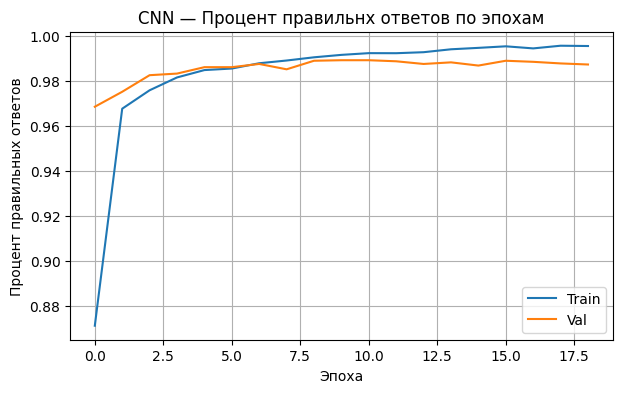

In [ ]:
cnn = nn.Sequential(
    # свёрточный блок 1
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),        # 28×28 - 14×14

    # свёрточный блок 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(2),        # 14×14 - 7×7

    # классификатор
    nn.Flatten(),           # 64×7×7 = 3136
    nn.Linear(3136, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10)
).to(device)

print("Архитектура CNN:")
print(cnn)


train_loader_cnn = DataLoader(DigitDataset(X_train, y_train, mode='image'), batch_size=128, shuffle=True)
val_loader_cnn   = DataLoader(DigitDataset(X_val,   y_val,   mode='image'), batch_size=128)
test_loader_cnn  = DataLoader(DigitDataset(X_test,            mode='image'), batch_size=128)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

train_accs, val_accs = [], []

for epoch in range(1, 20):
    _, tr_acc = train_epoch(cnn, train_loader_cnn, criterion, optimizer)
    _, vl_acc = evaluate(cnn, val_loader_cnn, criterion)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f"Эпоха {epoch:02d} | точность на обучении: {tr_acc:.4f} | точность на валидации: {vl_acc:.4f}")

print(f"\nCNN и итоговая точность на валидации: {val_accs[-1]*100:.2f}%")
plot_history(train_accs, val_accs, 'CNN')

Модель     Точность на валидации
MLP                 97.71%
CNN                 98.74%


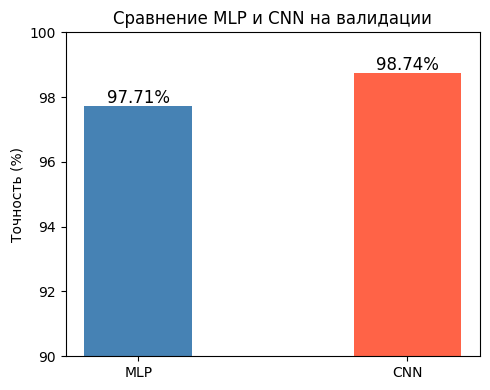

In [ ]:
# точность на валидации
criterion = nn.CrossEntropyLoss()

_, mlp_acc = evaluate(mlp, val_loader,     criterion)
_, cnn_acc = evaluate(cnn, val_loader_cnn, criterion)

print(f"{'Модель':<10} {'Точность на валидации':>15}")
print(f"{'MLP':<10} {mlp_acc*100:>14.2f}%")
print(f"{'CNN':<10} {cnn_acc*100:>14.2f}%")

models = ['MLP', 'CNN']
accs   = [mlp_acc * 100, cnn_acc * 100]

plt.figure(figsize=(5, 4))
bars = plt.bar(models, accs, color=['steelblue', 'tomato'], width=0.4)
plt.ylim(90, 100)
plt.ylabel('Точность (%)')
plt.title('Сравнение MLP и CNN на валидации')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image, ImageOps
from google.colab import files
import io

print("Загрузка фото:")
uploaded = files.upload()

def prepare_photo(img_bytes):
    img = Image.open(io.BytesIO(img_bytes)).convert('L')  # grayscale
    img = ImageOps.invert(img)                             # белый фон на чёрный
    img = img.resize((28, 28), Image.LANCZOS)              # resize 28×28
    arr = np.array(img, dtype='float32') / 255.0

    # для инверсии цвета цифры
    if arr.mean() > 0.5:
        arr = 1.0 - arr

    return arr

my_imgs, my_names = [], []
for fname, fdata in uploaded.items():
    my_imgs.append(prepare_photo(fdata))
    my_names.append(fname)

my_imgs = np.array(my_imgs)

# предсказание
cnn.eval()
tensor = torch.tensor(my_imgs).unsqueeze(1).to(device)
with torch.no_grad():
    probs = torch.softmax(cnn(tensor), dim=1).cpu().numpy()
preds = probs.argmax(axis=1)
confs = probs.max(axis=1)

# визуализация
n    = len(my_imgs)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
axes = np.array(axes).flatten()

for i in range(len(axes)):
    if i < n:
        axes[i].imshow(my_imgs[i], cmap='gray')
        axes[i].set_title(f"Pred: {preds[i]}\n{confs[i]*100:.0f}%")
    axes[i].axis('off')

plt.suptitle('CNN')
plt.tight_layout()
plt.show()

Загрузка фото:
